In [33]:
import matplotlib.pyplot as plt
import os
import sys
sys.path.append('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/scripts')
from mge_general import MGEFitter
from astropy.io import fits
import numpy as np
import mgefit as mge
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

In [3]:
# the file is a csv with the format:
# X;Y;LOSV;LOSV_err;sigma;sigma_err;h3;h4
kin_table = Table.read("/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/IFU/antoine/M104_stellar_Kin.csv", format="csv", delimiter=";")

In [34]:
# def plot_map(x, y, values, cmap='RdBu_r', cbar_label='Value', ax=None, show=True):
#     # takes the xy and values and plots as an image with a colorbar
#     # create a grid of x and y values
#     xi = np.linspace(np.min(x), np.max(x), 100)
#     yi = np.linspace(np.min(y), np.max(y), 100)
#     xi, yi = np.meshgrid(xi, yi)
#     # interpolate the values onto the grid
#     from scipy.interpolate import griddata
#     zi = griddata((x, y), values, (xi, yi), method='cubic')
#     # plot the image
#     if ax is None:
#         fig, ax = plt.subplots(figsize=(8, 8))
#     im = ax.imshow(zi, extent=(np.min(x), np.max(x), np.min(y), np.max(y)), origin='lower', cmap=cmap)
#     plt.colorbar(im, ax=ax, label=cbar_label)
#     ax.set_xlabel('X (arcsec)')
#     ax.set_ylabel('Y (arcsec)')
#     #ax.set_title('Interpolated Map')
#     if show:
#         plt.show()
    
def plot_map(x, y, values, cmap='RdBu_r', cbar_label='Value',
              ax=None, show=True, vmin=None, vmax=None, cbar=True):
    # takes the xy and values and plots as an image with a colorbar
    # create a grid of x and y values
    xi = np.linspace(np.min(x), np.max(x), 100)
    yi = np.linspace(np.min(y), np.max(y), 100)
    xi, yi = np.meshgrid(xi, yi)
    # interpolate the values onto the grid
    zi = griddata((x, y), values, (xi, yi), method='cubic')
    # plot the image
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(zi, extent=(np.min(x), np.max(x), np.min(y), np.max(y)),
                    origin='lower', cmap=cmap, vmin=vmin, vmax=vmax)
    if cbar:
        plt.colorbar(im, ax=ax, label=cbar_label, pad=0.01)
    ax.set_xlabel('X (arcsec)')
    ax.set_ylabel('Y (arcsec)')
    if show:
        plt.show()


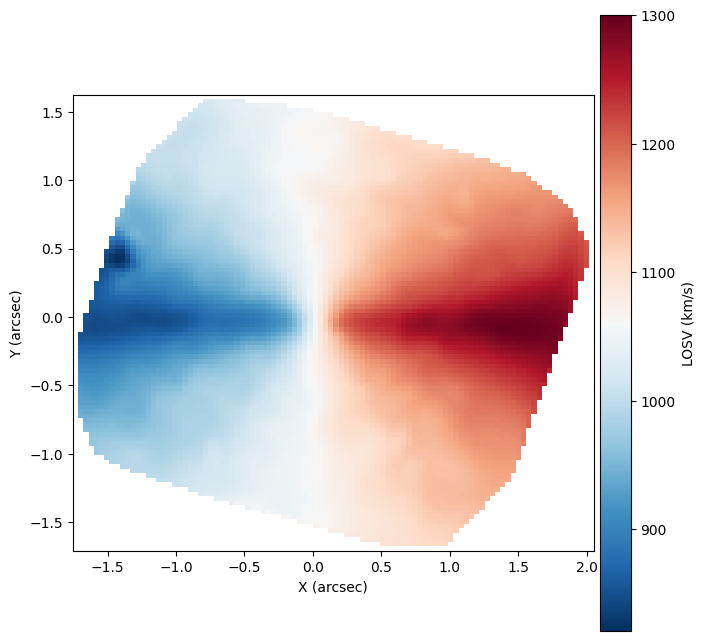

In [35]:
# load the NIRSpec kinematic data
# this is not aligned with the photometry, it is in IFU alignment. We will need to rotate and shift it to match the photometry. The center is at (0, 0) in this table, which seems to match the center  of the galaxy.
# rotation to go from IFU alignment to photometry alignment is about 20 degrees.
def rotate(x, y, angle_deg):
    angle_rad = np.radians(angle_deg)
    x_rot = x * np.cos(angle_rad) - y * np.sin(angle_rad)
    y_rot = x * np.sin(angle_rad) + y * np.cos(angle_rad)
    return x_rot, y_rot
kin_table["X_rot"], kin_table["Y_rot"] = rotate(kin_table["X"],
                                                 kin_table["Y"], -18)

# plot the rotated LOSV map

plot_map(kin_table["X_rot"], kin_table["Y_rot"], kin_table["LOSV"], cbar_label='LOSV (km/s)') 


In [6]:
# load the MUSE kinematic data from the data products of emiles
muse = fits.open("/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/c_30_1_results/c30_DATACUBE_normppxf_skycont_Part1_0000_ppxf_products_emiles.fits")

In [26]:
# substract the systemic velocity to the NIRSpec LOSV map to match the MUSE data, which is already substracted
kin_table["LOSV_sub"] = kin_table["LOSV"] - np.mean(kin_table["LOSV"])

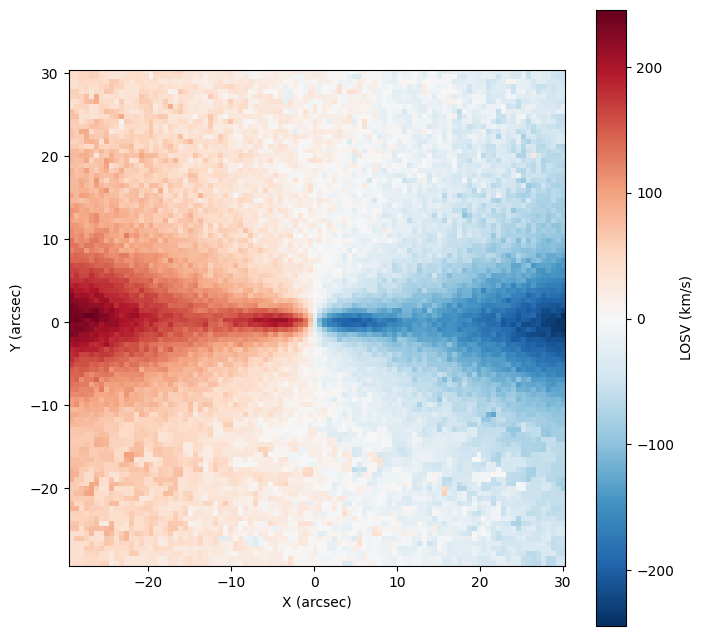

In [17]:
plot_map(muse[2].data['X_ARCSEC'], muse[2].data['Y_ARCSEC'], muse[2].data['V_KMS'], cbar_label='LOSV (km/s)')

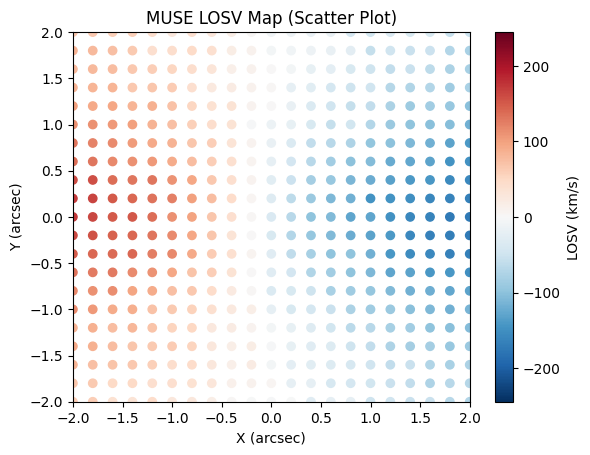

In [52]:
# plot the map as a simple scatter plot to see the distribution of the points
plt.scatter(muse[2].data['X_ARCSEC'], muse[2].data['Y_ARCSEC'], c=muse[2].data['V_KMS'], cmap='RdBu_r')
plt.colorbar(label='LOSV (km/s)')
plt.xlabel('X (arcsec)')
plt.ylabel('Y (arcsec)')
plt.title('MUSE LOSV Map (Scatter Plot)')
# 
plotting_lim = 2
plt.xlim(-plotting_lim, plotting_lim)
plt.ylim(-plotting_lim, plotting_lim)
plt.show()

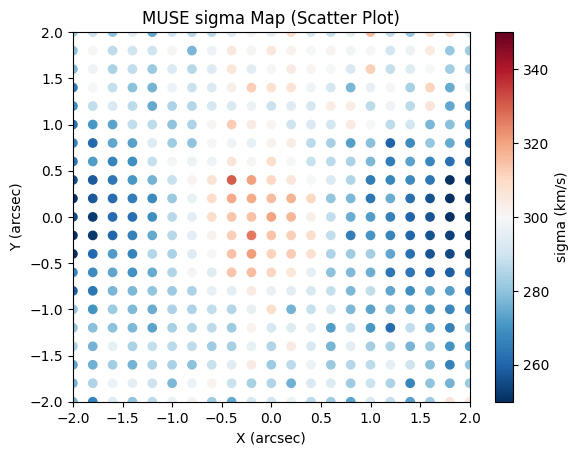

In [54]:
# plot the map as a simple scatter plot to see the distribution of the points
plt.scatter(muse[2].data['X_ARCSEC'], muse[2].data['Y_ARCSEC'], c=muse[2].data['SIGMA_KMS'], cmap='RdBu_r',
vmin=250, vmax=350)
plt.colorbar(label='sigma (km/s)')
plt.xlabel('X (arcsec)')
plt.ylabel('Y (arcsec)')
plt.title('MUSE sigma Map (Scatter Plot)')
# 
plotting_lim = 2
plt.xlim(-plotting_lim, plotting_lim)
plt.ylim(-plotting_lim, plotting_lim)
plt.show()

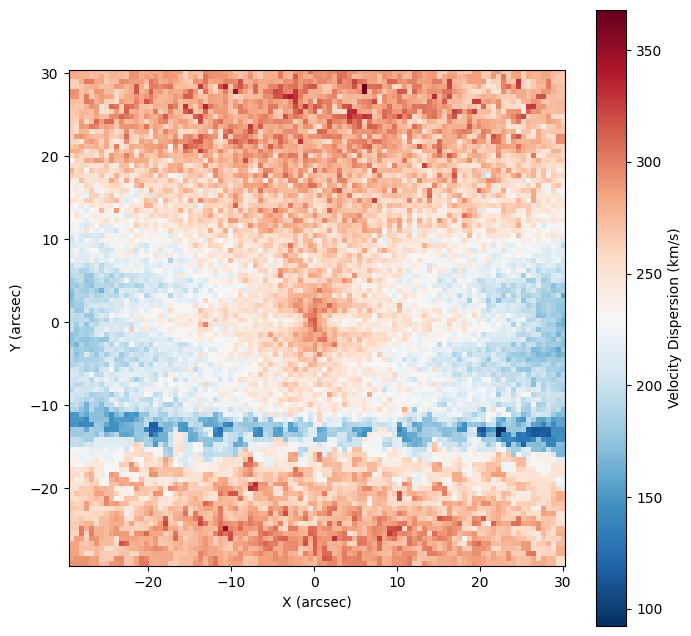

In [23]:
# plot the velocity dispersion map
plot_map(muse[2].data['X_ARCSEC'], muse[2].data['Y_ARCSEC'], muse[2].data['SIGMA_KMS'], cbar_label='Velocity Dispersion (km/s)')

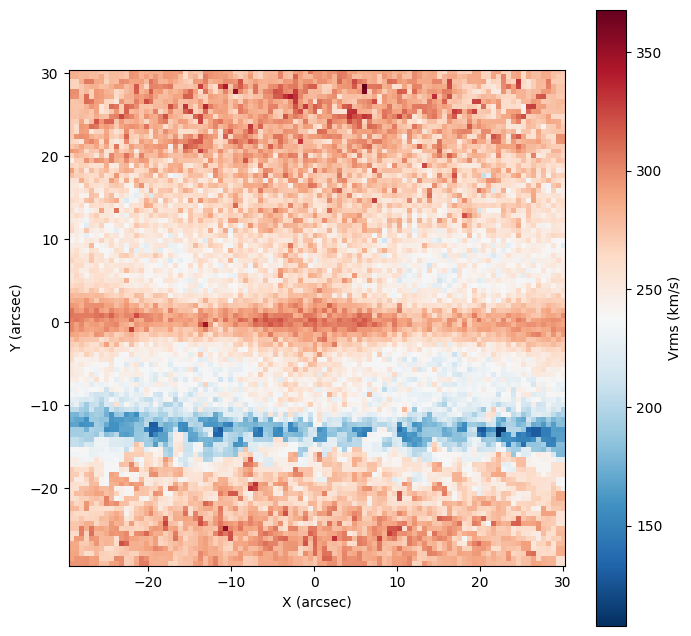

In [24]:
# plot the vrms map
vrms = np.sqrt(muse[2].data['V_KMS']**2 + muse[2].data['SIGMA_KMS']**2)
plot_map(muse[2].data['X_ARCSEC'], muse[2].data['Y_ARCSEC'], vrms, cbar_label='Vrms (km/s)')

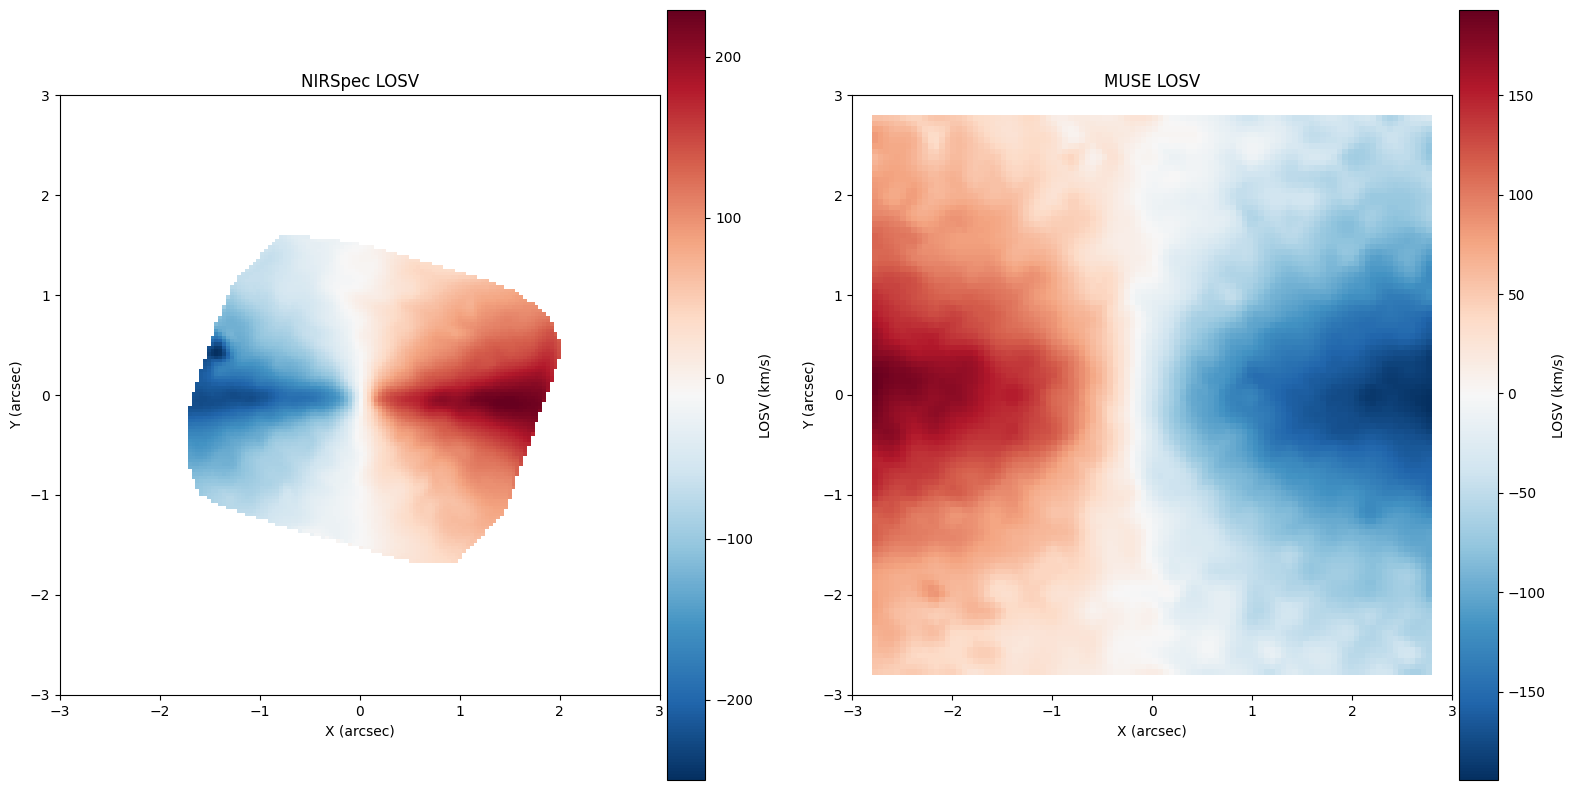

In [72]:
plotting_lim = 3
# plot a side to side view of the velocity maps from MUSE and NIRSpec
fig, axs = plt.subplots(1, 2, figsize=(16, 8))
plot_map(kin_table["X_rot"], kin_table["Y_rot"], kin_table["LOSV_sub"], cbar_label='LOSV (km/s)', ax=axs[0], show=False) 
axs[0].set_title("NIRSpec LOSV")
# mask out the values outside the plotting limits in the MUSE map
mask = (muse[2].data['X_ARCSEC'] > -plotting_lim) & (muse[2].data['X_ARCSEC'] < plotting_lim)
mask &= (muse[2].data['Y_ARCSEC'] > -plotting_lim) & (muse[2].data['Y_ARCSEC'] < plotting_lim)
plot_map(muse[2].data['X_ARCSEC'][mask], muse[2].data['Y_ARCSEC'][mask], muse[2].data['V_KMS'][mask], cbar_label='LOSV (km/s)', ax=axs[1], show=False)
# restrict the x and y limits to be the same for both plots
axs[0].set_xlim(-plotting_lim, plotting_lim)
axs[1].set_xlim(-plotting_lim, plotting_lim)
axs[0].set_ylim(-plotting_lim, plotting_lim)
axs[1].set_ylim(-plotting_lim, plotting_lim)
axs[1].set_title("MUSE LOSV")
plt.tight_layout()
plt.show()

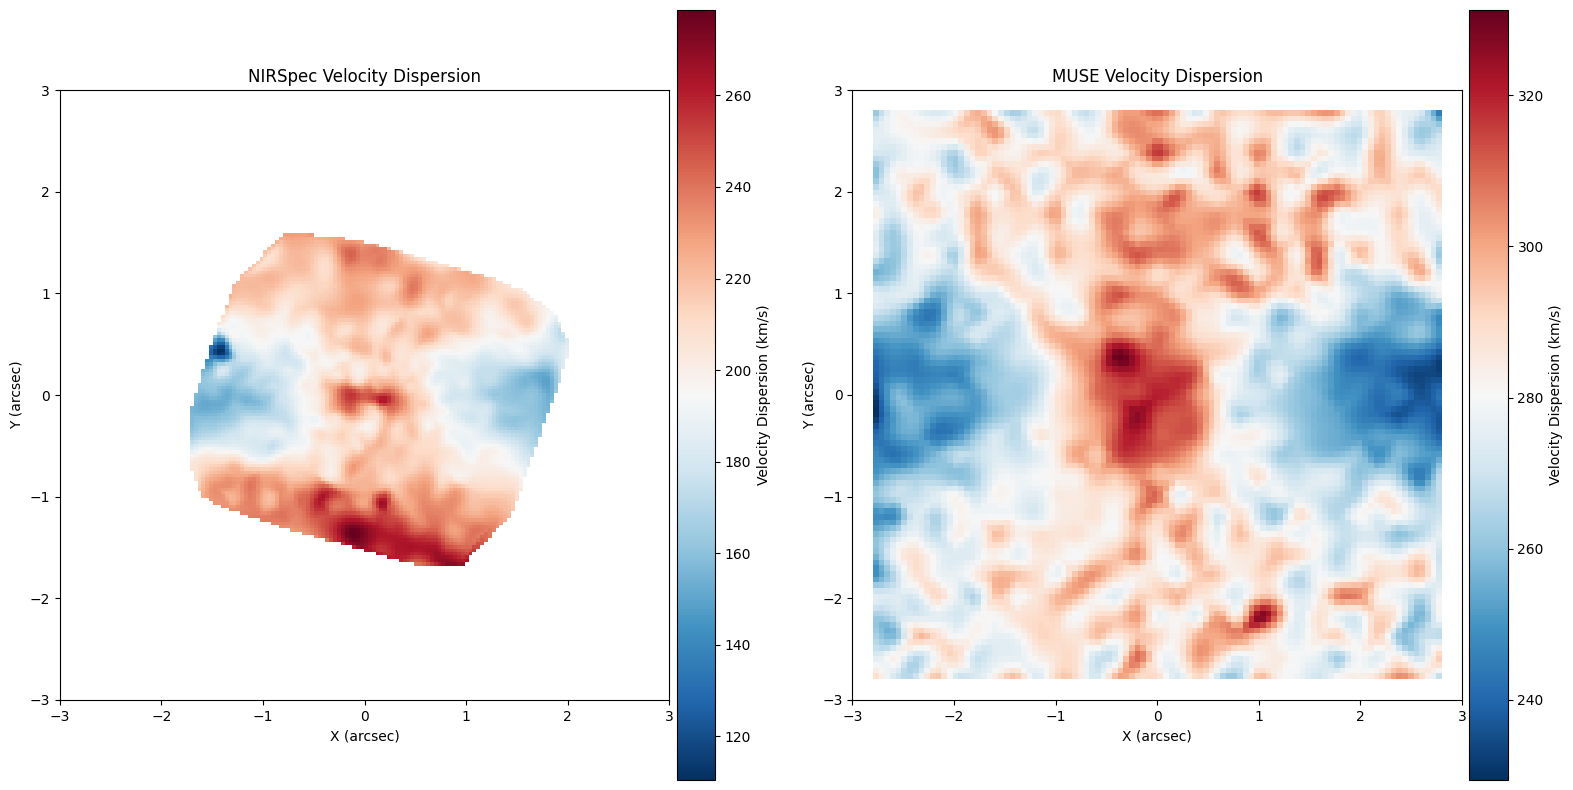

In [73]:
# now the same for the velocity dispersion maps
fig, axs = plt.subplots(1, 2, figsize=(16, 8))
plot_map(kin_table["X_rot"], kin_table["Y_rot"], kin_table["sigma"], cbar_label='Velocity Dispersion (km/s)', ax=axs[0], show=False) 
axs[0].set_title("NIRSpec Velocity Dispersion")
mask = (muse[2].data['X_ARCSEC'] > -plotting_lim) & (muse[2].data['X_ARCSEC'] < plotting_lim)
mask &= (muse[2].data['Y_ARCSEC'] > -plotting_lim) & (muse[2].data['Y_ARCSEC'] < plotting_lim)
plot_map(muse[2].data['X_ARCSEC'][mask], muse[2].data['Y_ARCSEC'][mask], muse[2].data['SIGMA_KMS'][mask], cbar_label='Velocity Dispersion (km/s)', ax=axs[1], show=False)
axs[1].set_title("MUSE Velocity Dispersion")
# restrict the x and y limits to be the same for both plots
axs[0].set_xlim(-plotting_lim, plotting_lim)
axs[1].set_xlim(-plotting_lim, plotting_lim)
axs[0].set_ylim(-plotting_lim, plotting_lim)
axs[1].set_ylim(-plotting_lim, plotting_lim)
plt.tight_layout()
plt.show()

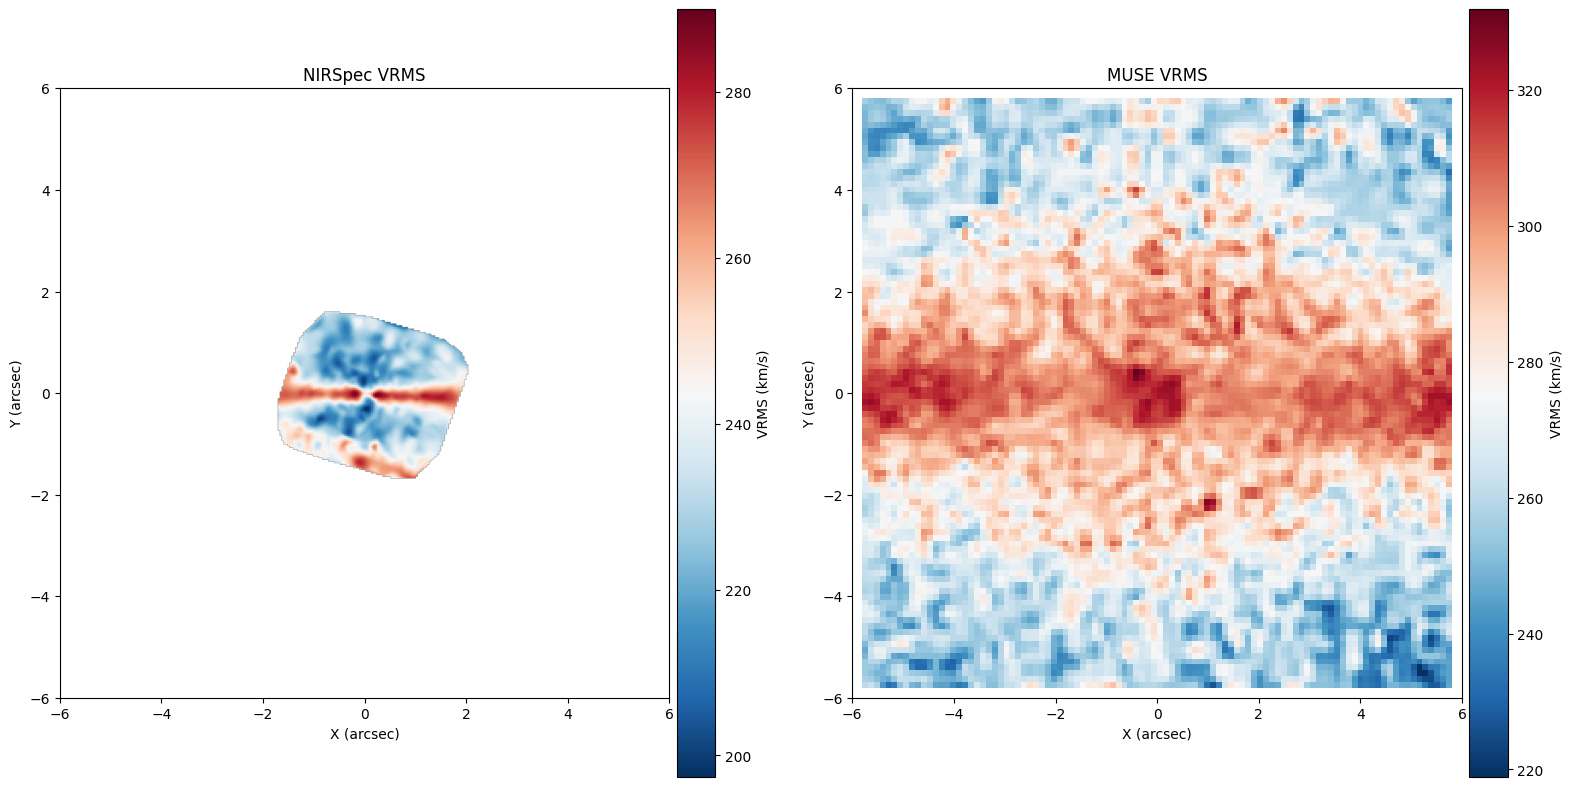

In [59]:
# now the VRMS maps
fig, axs = plt.subplots(1, 2, figsize=(16, 8))
plot_map(kin_table["X_rot"], kin_table["Y_rot"], np.sqrt(kin_table["LOSV_sub"]**2 + kin_table["sigma"]**2), cbar_label='VRMS (km/s)', ax=axs[0], show=False) 
axs[0].set_title("NIRSpec VRMS")
# mask out the values outside the plotting limits in the MUSE map
mask = (muse[2].data['X_ARCSEC'] > -plotting_lim) & (muse[2].data['X_ARCSEC'] < plotting_lim)
mask &= (muse[2].data['Y_ARCSEC'] > -plotting_lim) & (muse[2].data['Y_ARCSEC'] < plotting_lim)

plot_map(muse[2].data['X_ARCSEC'][mask], muse[2].data['Y_ARCSEC'][mask], np.sqrt(muse[2].data['V_KMS'][mask]**2 + muse[2].data['SIGMA_KMS'][mask]**2), cbar_label='VRMS (km/s)', ax=axs[1], show=False)
axs[1].set_title("MUSE VRMS")
# restrict the x and y limits to be the same for both plots
axs[0].set_xlim(-plotting_lim, plotting_lim)
axs[1].set_xlim(-plotting_lim, plotting_lim)
axs[0].set_ylim(-plotting_lim, plotting_lim)
axs[1].set_ylim(-plotting_lim, plotting_lim)
plt.tight_layout()
plt.show()

/var/folders/mw/xz5d5_4s6xz43rmhpz09kjrr0000gp/T/ipykernel_88061/1475940452.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


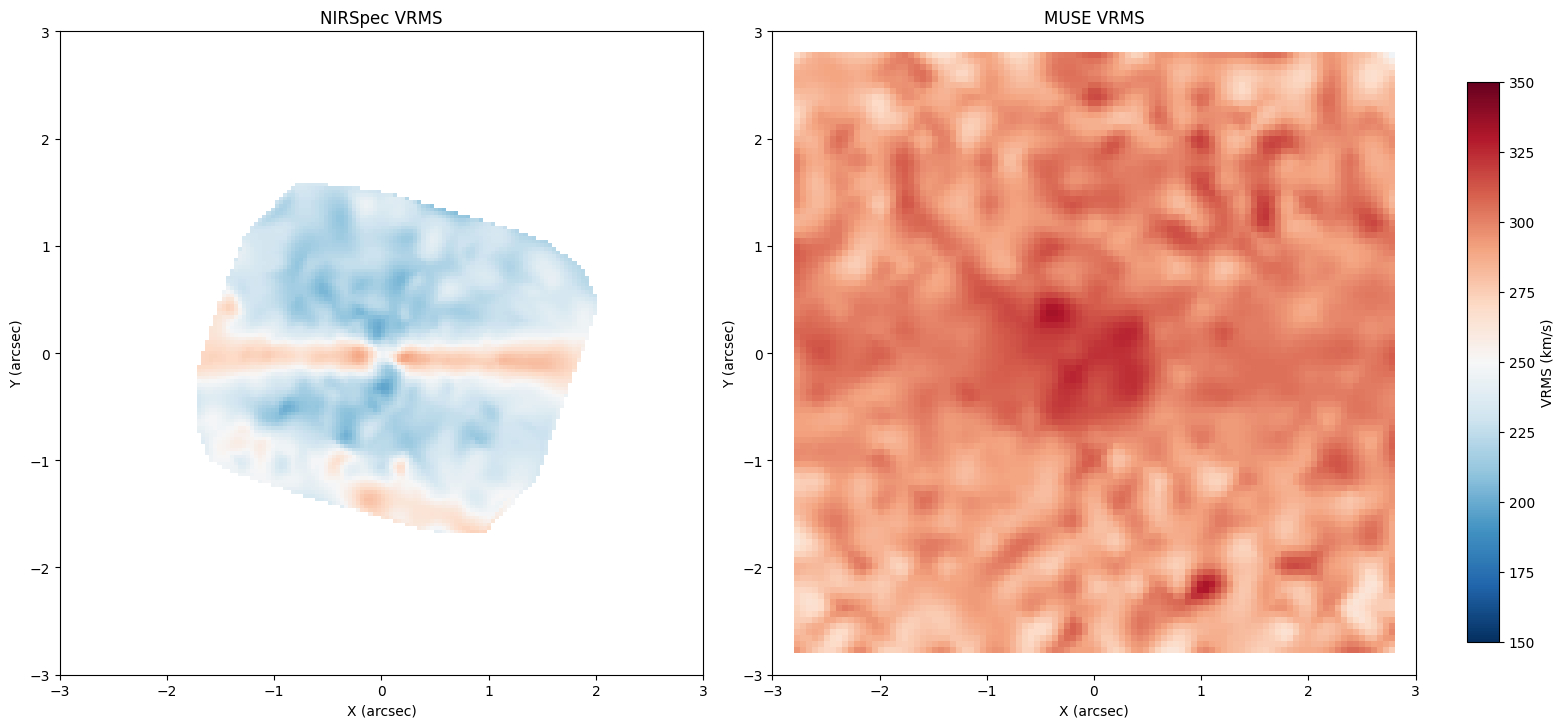

In [74]:
# plot the VRMS maps with the same colorbar limits to better compare the two
vmin = 150
vmax = 350
fig, axs = plt.subplots(1, 2, figsize=(16, 8))
plot_map(kin_table["X_rot"], kin_table["Y_rot"], np.sqrt(kin_table["LOSV_sub"]**2 + kin_table["sigma"]**2), 
cbar_label='VRMS (km/s)', ax=axs[0], show=False, vmin=vmin, vmax=vmax, cbar=False) 
axs[0].set_title("NIRSpec VRMS")
# mask out the values outside the plotting limits in the MUSE map
mask = (muse[2].data['X_ARCSEC'] > -plotting_lim) & (muse[2].data['X_ARCSEC'] < plotting_lim)
mask &= (muse[2].data['Y_ARCSEC'] > -plotting_lim) & (muse[2].data['Y_ARCSEC'] < plotting_lim)
plot_map(muse[2].data['X_ARCSEC'][mask], muse[2].data['Y_ARCSEC'][mask], np.sqrt(muse[2].data['V_KMS'][mask]**2 + muse[2].data['SIGMA_KMS'][mask]**2),
 cbar_label='VRMS (km/s)', ax=axs[1], show=False, vmin=vmin, vmax=vmax, cbar=False)
axs[1].set_title("MUSE VRMS")
# restrict the x and y limits to be the same for both plots
axs[0].set_xlim(-plotting_lim, plotting_lim)
axs[1].set_xlim(-plotting_lim, plotting_lim)
axs[0].set_ylim(-plotting_lim, plotting_lim)
axs[1].set_ylim(-plotting_lim, plotting_lim)
# add a single colorbar for both plots
cbar_ax_resid = fig.add_axes([0.92, 0.15, 0.02, 0.7])
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=norm)
cbar = plt.colorbar(sm, cax=cbar_ax_resid, label='Vrms (km/s)',
 ax=cbar_ax_resid, orientation='vertical', fraction=0.02, pad=0.01)
cbar.set_label('VRMS (km/s)')
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

/var/folders/mw/xz5d5_4s6xz43rmhpz09kjrr0000gp/T/ipykernel_88061/1563682666.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


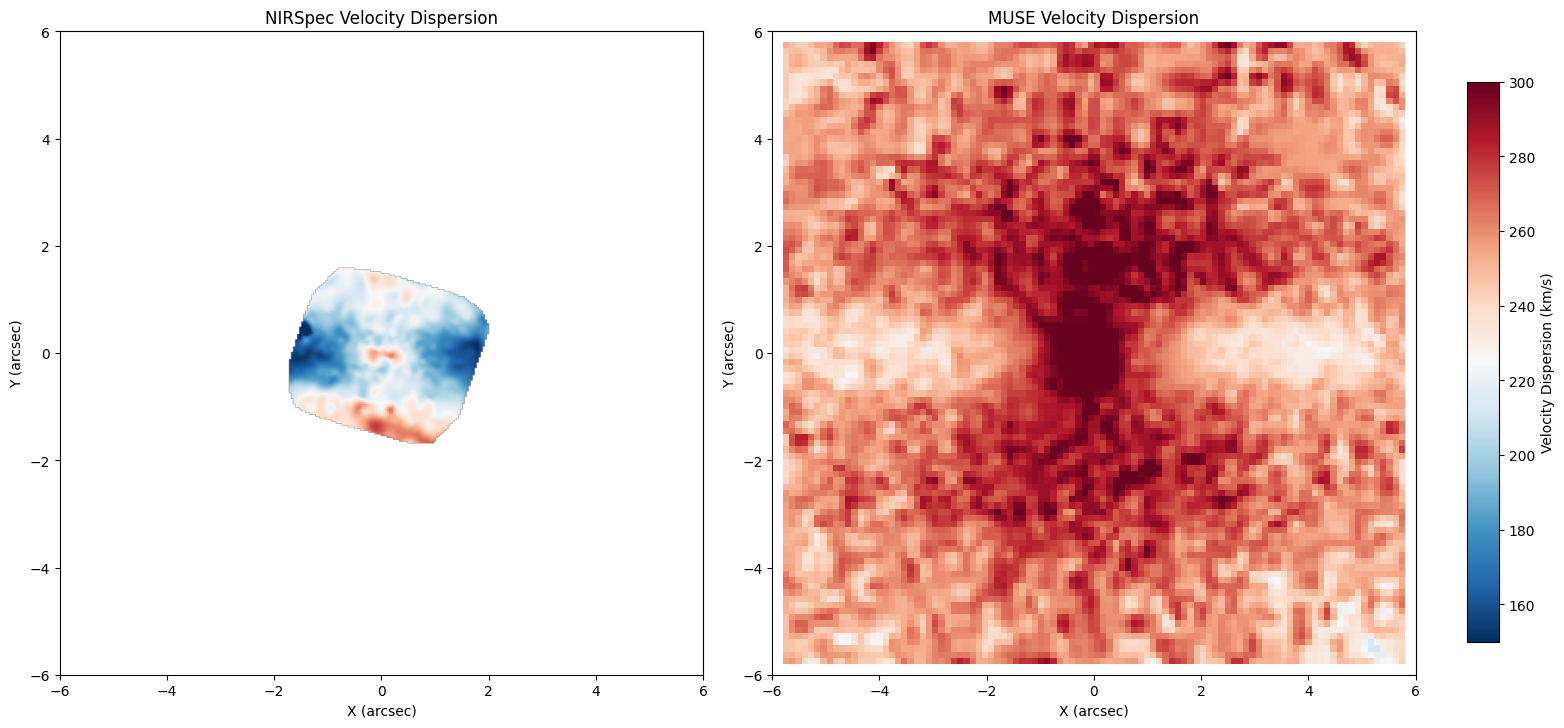

In [65]:
# same plot with a common colorbar for the velocity dispersion maps
vmin = 150
vmax = 300
fig, axs = plt.subplots(1, 2, figsize=(16, 8))
plot_map(kin_table["X_rot"], kin_table["Y_rot"], kin_table["sigma"], cbar_label='Velocity Dispersion (km/s)', ax=axs[0], show=False, vmin=vmin, vmax=vmax, cbar=False) 
axs[0].set_title("NIRSpec Velocity Dispersion")
plot_map(muse[2].data['X_ARCSEC'][mask], muse[2].data['Y_ARCSEC'][mask], muse[2].data['SIGMA_KMS'][mask], cbar_label='Velocity Dispersion (km/s)', ax=axs[1], show=False, vmin=vmin, vmax=vmax, cbar=False)
axs[1].set_title("MUSE Velocity Dispersion")
# restrict the x and y limits to be the same for both plots
axs[0].set_xlim(-plotting_lim, plotting_lim)
axs[1].set_xlim(-plotting_lim, plotting_lim)
axs[0].set_ylim(-plotting_lim, plotting_lim)
axs[1].set_ylim(-plotting_lim, plotting_lim)
# add a single colorbar for both plots
cbar_ax_resid = fig.add_axes([0.92, 0.15, 0.02, 0.7])
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=norm)
cbar = plt.colorbar(sm, cax=cbar_ax_resid, label='Velocity Dispersion (km/s)',
 ax=cbar_ax_resid, orientation='vertical', fraction=0.02, pad=0.01)
cbar.set_label('Velocity Dispersion (km/s)')
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()